In [1]:
import flag_mean
import flag_median
import load_mnist_data
import numpy as np
from matplotlib import pyplot as plt
from sklearn.manifold import mds
from sklearn.decomposition import PCA
import distances


def load_data(k = 5, ss_big = 500, digits = [0,1,2,3,4,5,6,7,8,9], st = 'train'):
    data = []
    labels_before = []
    for d in digits:
            [dta, lbl] = load_mnist_data.load_mnist_data(d, ss_big, st)
            for i in range(int(ss_big/k)):
                data.append(np.linalg.qr(dta[:,i*k:(i+1)*(k)])[0])
                labels_before.append(lbl[0])
    return [data,labels_before]

ss_big = 500
#gr(k,n), k<n and k must divide ss_big
k=5
#out_k is number of singular vectors (space for the median or the mean)
out_k = 5
#load the data
[data,labels_before] = load_data(k, ss_big, digits = [1])



/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.manifold.mds module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.manifold. Anything that cannot be imported from sklearn.manifold is now part of the private API.
  warnings.warn(message, FutureWarning)


In [4]:
median = flag_median.flag_median(data,.000001,k)
mean = flag_mean.flag_mean(data)

In [11]:
plot_data = data + [mean] + [median]

In [13]:
pairwise_dist = distances.chordal_distance(plot_data, plot_data, False)
data_transformed = distances.mds(pairwise_dist)

(-1.0, 1.0)

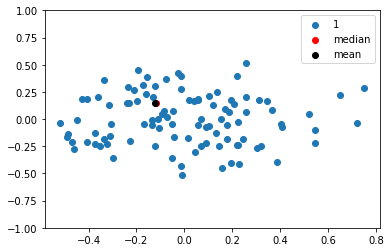

In [14]:
plt.scatter(data_transformed[:100,0], data_transformed[:100,1], label = '1')
plt.scatter(data_transformed[100,0], data_transformed[100,1], marker = 'o', c = 'r', label = 'median')
plt.scatter(data_transformed[101,0], data_transformed[101,1], marker = 'o', c= 'k', label = 'mean')
plt.legend()
plt.ylim(-1, 1)
plt.ylim(-1, 1)